In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.research.qcut_analyzer import QcutAnalyzer
# QcutAnalyzer.plot_qcut_analysis(df, col_a='Factor_A', col_b='Return')
from sdk_core import configure
from sdk_core import TwMarketData
# configure()
from src.research.rolling_model import train_and_predict_ridge_rolling

tw = TwMarketData()
# 取得還原股價
df = tw.get_security_price_adjusted("2025-12-31", "2330")

import os
import numpy as np
from tqdm import tqdm
import time
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
# 將最大顯示欄位數量設為 None（代表無上限）
pd.set_option('display.max_columns', None)

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import pyarrow as pa
schema = pa.schema([
    ('price', pa.decimal128(10, 4)), 
    # 其他欄位如果沒特別指定，pyarrow 會自動推斷
])

from src.research.backTest import BackTest


In [2]:

folder_path = './data'  # 資料夾路徑
files = os.listdir(folder_path)

# 過濾掉資料夾，只留下檔案
file_names = np.array([f for f in files if os.path.isfile(os.path.join(folder_path, f))])
file_names.sort()
print(file_names[-5:])

['20260414.parquet' '20260415.parquet' '20260416.parquet'
 '20260417.parquet' '20260420.parquet']


In [3]:
data = []

# 範例：處理 100 個檔案
for f in tqdm (file_names[250:]): 
    targetLabel = 'BidPrice1' 
    rankThres_btn = 0
    rankThres = 150
    stock_df = pd.read_parquet( f'{folder_path}/{f}' )[lambda x : x[targetLabel] * x.BidPrice1 > 0]
    try : 
        stock_df['ToRef'] = ((stock_df['BidPrice1'] - stock_df.RefPrice) / stock_df.RefPrice ).round(6)
        stock_df['ToOpen'] = ((stock_df['BidPrice1'] - stock_df.Open) / stock_df.Open ).round(6)
        # stock_df['TakerSell_CloseBP'] = ((stock_df[targetLabel]- stock_df.Close) / stock_df[targetLabel] * 10000)
        # stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.09 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.FutureHigh) / stock_df[targetLabel] * 10000)
        stock_df['TakerSell_CloseBP'] = ((stock_df[targetLabel]- stock_df.Close) / stock_df[targetLabel] * 10000)
        stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.08 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.RefPrice*1.08 - stock_df.TickSize*2) / stock_df[targetLabel] * 10000)
        PriceCondition = (stock_df.ToRef > -0.015) & (stock_df.ToRef < 0.05)
        # seqCondition = (stock_df.BidPrice1.diff()!= 0)
        AmountCondition = (stock_df.day_amount_rank <= rankThres) | (stock_df.AmountRank_canDayTrade <= rankThres) 
        # AmountCondition2 = (stock_df.day_amount_rank > rankThres_btn) & (stock_df.AmountRank > rankThres_btn)
        # preMarketCondition = (stock_df.day_amount_rank <= 50.1) | (stock_df.AmountRank <= 50.1)
        temp = stock_df[ PriceCondition & AmountCondition].reset_index(drop=True)
        temp['Date'] = f.split('.')[0]
        data.append(temp)
    except : 
        print('Filled in ', f)
        continue
        # break       
    # if f.split('.')[0] == '20260309':
    #     break

100%|██████████| 540/540 [01:15<00:00,  7.12it/s]


In [195]:
signal_df = pd.concat(data).reset_index(drop=True)
priceReturnColumn = ["TransTime", "QuoteCode", "ChannelSeq","TotalFillLots","BidPrice1","BidLots1", "AskPrice1","AskLots1", "RecordHigh","FutureHigh", "RefPrice" , "Close" , "Open", "Spread", "TakerSell_CloseBP" ]
signal_df[:][priceReturnColumn + ['ToRef','FillLots_atLow','day_amount_rank', 'AmountRank', 'TimeSlot','TransTime_tb']].head(10)

,TransTime,QuoteCode,ChannelSeq,TotalFillLots,BidPrice1,BidLots1,AskPrice1,AskLots1,RecordHigh,FutureHigh,RefPrice,Close,Open,Spread,TakerSell_CloseBP,ToRef,FillLots_atLow,day_amount_rank,AmountRank,TimeSlot,TransTime_tb
0,2024-01-18 09:01:59.901908,1101,210490,232,32.25,2,32.30,21,32.25,32.35,32.2,32.05,32.2,1.0,62.015504,0.001553,-88,102.0,NaN,None,NaT
1,2024-01-18 09:02:49.046158,1101,263433,273,32.35,2,32.40,18,32.35,32.35,32.2,32.05,32.2,1.0,92.735703,0.004658,-55,102.0,NaN,None,NaT
2,2024-01-18 09:02:49.078622,1101,263458,275,32.30,11,32.40,18,32.35,32.35,32.2,32.05,32.2,2.0,77.399381,0.003106,-57,102.0,NaN,None,NaT
3,2024-01-18 09:02:54.206873,1101,268087,275,32.35,2,32.40,18,32.35,32.35,32.2,32.05,32.2,1.0,92.735703,0.004658,-57,102.0,NaN,None,NaT
4,2024-01-18 09:02:54.243209,1101,268111,277,32.30,10,32.40,18,32.35,32.35,32.2,32.05,32.2,2.0,77.399381,0.003106,-59,102.0,NaN,None,NaT
5,2024-01-18 09:03:00.003879,1101,273412,297,32.25,14,32.35,7,32.35,32.35,32.2,32.05,32.2,2.0,62.015504,0.001553,-79,102.0,NaN,None,NaT
6,2024-01-18 09:03:01.061515,1101,274527,299,32.30,1,32.35,20,32.35,32.35,32.2,32.05,32.2,1.0,77.399381,0.003106,-81,102.0,NaN,None,NaT
7,2024-01-18 09:03:01.230883,1101,274664,300,32.25,16,32.35,17,32.35,32.35,32.2,32.05,32.2,2.0,62.015504,0.001553,-82,102.0,NaN,None,NaT
8,2024-01-18 09:10:33.106627,1101,663222,659,32.30,1,32.35,18,32.35,32.35,32.2,32.05,32.2,1.0,77.399381,0.003106,-7,102.0,239.0,09:10:00,2024-01-18 09:09:58.736650
9,2024-01-18 09:10:33.164840,1101,663279,660,32.25,36,32.35,18,32.35,32.35,32.2,32.05,32.2,2.0,62.015504,0.001553,-8,102.0,239.0,09:10:00,2024-01-18 09:09:58.736650


In [196]:
signal_df = signal_df[ (signal_df.TransTime.dt.time < datetime.time(12, 0, 0)) & (signal_df.TransTime.dt.time > datetime.time(9, 0, 30)) & (signal_df.TrialMatch == 0)].reset_index(drop=True)
signal_df = signal_df[  (signal_df.TakerSell_CloseBP.abs() < 10000) ].sort_values(['Date', 'QuoteCode', 'TransTime']).reset_index(drop=True)
signal_df['midEdge_300sBP'] = signal_df['midEdge_300sBP']*-1

<Axes: xlabel='Date'>

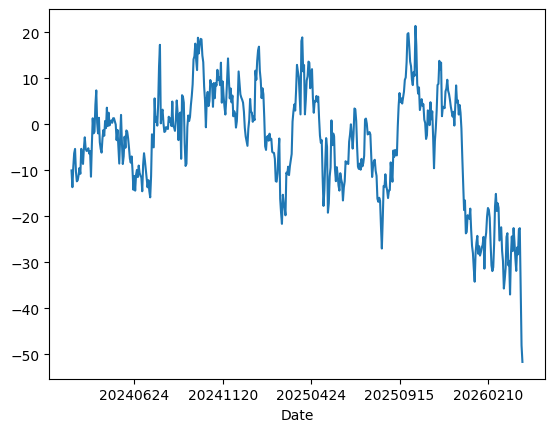

In [197]:
signal_df[:].groupby(['Date','QuoteCode']).TakerSell_CloseBP.mean().reset_index().groupby(['Date']).TakerSell_CloseBP.mean().rolling(30).mean().plot()

In [198]:
signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby(['Date','QuoteCode']).TakerSell_CloseBP.transform('mean')#.clip(lower=-130, upper=130)
# signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby(['Date','QuoteCode']).TakerSell_CloseBP.transform('mean')#.clip(lower=-130, upper=130)
# signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby(['Date']).TakerSell_CloseBP.transform('mean')

In [199]:
daily_market_mean = (
    signal_df.groupby(['Date', 'QuoteCode'])['TakerSell_CloseBP'].mean()  # 確保每檔股票每日只有一筆，等權重
    .groupby('Date').mean()                                               # 算全市場每日平均
)
# 2. 計算過去 20 天滾動平均，並用 .shift(1) 往後退一天 (避免使用到當天未來的收盤結果)
rolling_20d_market_mean = daily_market_mean.rolling(window=20).mean().shift(1)
# 3. 透過 'Date' 欄位，將算好的每一天市場平均，完美 map 回每一個 Tick 上！
signal_df['20day_marketBeta'] = signal_df['Date'].map(rolling_20d_market_mean)

In [200]:
import pandas as pd
import json

# 1. 讀取 JSON 檔案還原成 list
with open('abnormal_dates.json', 'r') as f:
    loaded_date_list = json.load(f)

signal_df['isAbnormalDate'] = signal_df['Date'].isin(loaded_date_list) *1

signal_df

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,FillLots_origin,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,BidPreMove,AskPreMove,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadCountAtSameCount,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,SpreadPairTotalCount,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,trading_net_volume_noOdd,trading_net_volume_nearClose,avg_bidLots1,avg_askLots1,last_fillLots,last_FillPrice,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,hft_strick_participation,hft_strick_buy_ToCloseBP,hft_strick_buy_300sBP,hft_strick_sell_ToCloseBP,hft_strick_sell_300sBP,hft_strick_makerSpreadBP,firstMaker_buy_ToCloseBP,firstMaker_buy_300sBP,firstMaker_sell_ToCloseBP,firstMaker_sell_300sBP,firstMaker_makerSpreadBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,premium_ref_2330_buy_ToCloseBP,premium_open_2330_buy_ToCloseBP,discount_ref_2330_buy_ToCloseBP,discount_open_2330_buy_ToCloseBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,AmountRank_canDayTrade,Date,TakerSell_CloseBP_net,20day_marketBeta,isAbnormalDate
0,2024-01-18 09:01:59.901908,2024-01-18 09:01:59.901908,1101,1101,1013501,210490,0,0,0,0,232,32.25,32.20,32.15,32.10,32.05,2,45,70,133,173,32.3,32.35,32.4,32.45,32.5,21,7,3,8,57,0.00,0,0.0,0,0.0,0,NaN,0,32.2,False,True,32.2,32.05,32.25,32.2,32.35,32.0,0.001553,0.000000,1.000000,0.05,0.0,0.05,15.503876,32.275,0.001553,0.001553,-88,34,-88,0.086957,0.004728,0.111111,0.218750,0.291667,1.0,1,32.3,32.2,1,0.0,0.000016,0.000016,1.0,6,226,1,15780,32.30,32.25,32.3,32.25,32.35,32.30,32.30,32.25,32.3,32.25,32.30,32.25,62.015504,-77.399381,0.000000,0.000000,15.491867,0.000000,-0.000000,0.000000,X,28856602.0,-158071.0,864561.0,0.0,-7125296.0,497000.0,99.0,-462.0,X,28452.0,19.0,2598.0,478.064112,203.753599,3408.0,-0.002324,14.0,-36.067935,-3.322412,10.0,26.558476,10.099288,0.596346,-56.486543,-21.209589,33.173189,14.643845,0.468114,-59.386316,-22.032844,26.644674,10.500194,-62.849162,-53.972245,-17.139100,31.599034,12.712205,-7.720219,-0.96846,15.617737,0.160553,NaN,-113.324784,-35.234905,-30.912876,102.0,38.0,NaT,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20240118,38.697612,NaN,0
1,2024-01-18 09:02:49.046158,2024-01-18 09:02:49.046158,1101,1101,1066444,263433,0,0,0,0,273,32.35,32.30,32.25,32.20,32.15,2,11,27,56,72,32.4,32.45,32.5,32.55,32.6,18,19,42,12,48,0.00,0,0.0,0,0.0,0,NaN,0,32.2,False,True,32.2,32.05,32.35,32.2,32.35,32.0,0.004658,0.000000,1.000000,0.05,0.0,0.05,15.455951,32.375,0.004658,0.004658,-55,8,-55,0.100000,0.011905,0.077381,0.129496,0.266187,1.0,2,32.4,32.3,1,1.0,4.558001,4.558001,1.0,10,37,2,15730,32.40,32.30,32.3,32.25,32.30,32.25,32.25,32.20,32.3,32.25

In [201]:
signal_df['B1_Last'] = signal_df.BidLots1 / signal_df.avg_bidLots1
signal_df['Total_Last'] = signal_df.TotalFillLots / signal_df.last_fillLots


In [202]:
based_columns = ['QuoteCode', 'ChannelSeq', 'InOut', 'Overshoot', 'TotalFillLots', 'BidPrice1','BidLots1', 'BidLots5', 'AskPrice1', 'AskLots1', 'AskLots5', 'FillLots']
feature_columns = ['ToLow', 'ToHigh', 'Low_High', 'TickSize', 'TickBP', 'ToRef', 'ToOpen', 'B1_A1B1', 'B1_B1B5', 'B12_B1B5', 'A1_A1A5', 'A12_A1A5', 'Spread', 'RemainSeconds']#'B1_Last','Total_Last']
cross_columns = ['AmountRank', 'netAmountRank', 'TotalFillLotsRank', 'netTotalFillLotsRank', 'ToRefRank']
day_columns = ['dealer_hedging_netLots', 'dealer_netLots', 'foreign_dealer_netLots', 'foreign_netLots', 'investment_netLots', 'margin_netLots', 'short_netLots', 'nextday_allow_day_trade_mark', 'trading_volume_noOdd', 'big_buy_lots', 'big_buy_ToCloseBP', 'big_buy_300sBP', 'big_sell_lots', 'big_sell_ToCloseBP', 'big_sell_300sBP', 'hft_participation', 'hft_buy_ToCloseBP', 'hft_buy_300sBP', 'hft_sell_ToCloseBP', 'hft_sell_300sBP', 'day_amount_rank', 'day_lots_rank']
# # 
feature = based_columns + feature_columns + cross_columns + day_columns
label = 'TakerSell_CloseBP_net'

feature_columns = ['ToLow', 'ToHigh', 'Low_High', 'ToRef', 'ToOpen', 'B1_A1B1', 'RemainSeconds']

In [203]:
for c in feature_columns : 
    signal_df[c] = signal_df[c].round(6)
signal_df ['OTC'] = signal_df ['OTC'] * 1
signal_df ['isInvestBuy'] = ( ( signal_df ['investment_netLots']  > 1000)  ) * 1 

signal_df_keep = signal_df.copy()

In [204]:
# result_100 = train_and_predict_ridge_rolling(signal_df[signal_df.BidPrice1 < 100], feature_columns , label, n_training_days=60, feature_screening=True, alpha=0.1 , max_position_per_stock = 500)
#signal_df = pd.concat([result['df'] , result_100['df']]).sort_values(['Date', 'QuoteCode', 'TransTime']).reset_index(drop=True)
# result = train_and_predict_ridge_rolling(signal_df[:], feature_columns , label, n_training_days=60, feature_screening=True, alpha=0.1 , max_position_per_stock = 500)
result = train_and_predict_ridge_rolling(signal_df[:], feature_columns , label, forced_masks = ['isInvestBuy'] ,n_training_days=60, feature_screening=True, alpha=0.1 , max_position_per_stock = 500)

🔍 目前預測目標: TakerSell_CloseBP_net | Rolling Training 視窗: 60 天
🔄 為了 O(1) NumPy 加速，強制將資料依照 Date, QuoteCode, TransTime 進行排序...
📊 資料總筆數: 10750182
🔄 填補特徵遺失值 (依據前一交易日之中位數)...
----------------------------------------
🚀 總輸入 current_X (共 8 個)
   - Tick Baseline: 7 個
   - Day Features:  0 個
   - Forced Masks:  1 個
----------------------------------------
🔄 計算 Lot Mask 與準備 NumPy 陣列
🔬 Phase 1: 預先計算 Feature Screening (worker: 16)...


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    0.6s
[Parallel(n_jobs=16)]: Done  40 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done  53 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done  66 tasks      | elapsed:    1.9s
[Parallel(n_jobs=16)]: Done  81 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done  96 tasks      | elapsed:    3.0s
[Parallel(n_jobs=16)]: Done 113 tasks      | elapsed:    3.7s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    4.4s
[Parallel(n_jobs=16)]: Done 149 tasks      | elapsed:    5.3s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    5.9s
[Parallel(n_jobs=16)]: Done 189 tasks      | elapsed:    7.1s
[Parallel(n_jobs=16)]: Done 210 tasks      | elapsed:    7.9s
[Parallel(n_jobs=16)]: Done 233 tasks      | elaps

✅ Phase 1 完成！
▶️ Phase 2: Rolling Update (Core: -1)...


[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done  49 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:   10.4s
[Parallel(n_jobs=-1)]: Done 117 tasks      | elapsed:   13.3s
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   15.7s
[Parallel(n_jobs=-1)]: Done 157 tasks      | elapsed:   18.2s
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:   21.0s
[Parallel(n_jobs=-1)]: Done 201 tasks      | elapsed:   23.9s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:   26.7s
[Parallel(n_jobs=-1)]: Done 249 tasks      | elapsed:   30.3s
[Parallel(n_jobs=-1)]: Done 274 tasks      | elapsed:   33.3s
[Parallel(n_jobs=-1)]: Done 301 tasks      | elapsed:   36.6s
[Paralle

✅ 平行 Rolling 更新預測完成！


In [205]:
screening_log = result['screening_log']   # {日期: [被選中的特徵名]}
coeff_log = result['coeff_log']           # {日期: {normal_coeff, normal_std_coeff, ...}}
signal_df = result['df']           # 原本的 DataFrameㄌ

In [206]:
coeff_log

{'2024-01-19': {'selected_features': ['isInvestBuy',
   'ToLow',
   'ToHigh',
   'Low_High',
   'ToRef',
   'ToOpen',
   'B1_A1B1',
   'RemainSeconds',
   'isInvestBuy_x_ToLow',
   'isInvestBuy_x_ToHigh',
   'isInvestBuy_x_Low_High',
   'isInvestBuy_x_ToRef',
   'isInvestBuy_x_ToOpen',
   'isInvestBuy_x_B1_A1B1',
   'isInvestBuy_x_RemainSeconds'],
  'normal_coeff': {'isInvestBuy': 55.23211669921875,
   'ToLow': -336.5146484375,
   'ToHigh': -930.9277954101562,
   'Low_High': -16.247098922729492,
   'ToRef': 3165.882568359375,
   'ToOpen': 18.729991912841797,
   'B1_A1B1': -15.271305084228516,
   'RemainSeconds': 0.010522851720452309,
   'isInvestBuy_x_ToLow': -46.42299270629883,
   'isInvestBuy_x_ToHigh': 1083.1806640625,
   'isInvestBuy_x_Low_High': 76.07119750976562,
   'isInvestBuy_x_ToRef': -698.4620971679688,
   'isInvestBuy_x_ToOpen': -609.5535888671875,
   'isInvestBuy_x_B1_A1B1': -10.064812660217285,
   'isInvestBuy_x_RemainSeconds': -0.007127596065402031},
  'normal_std_coeff'

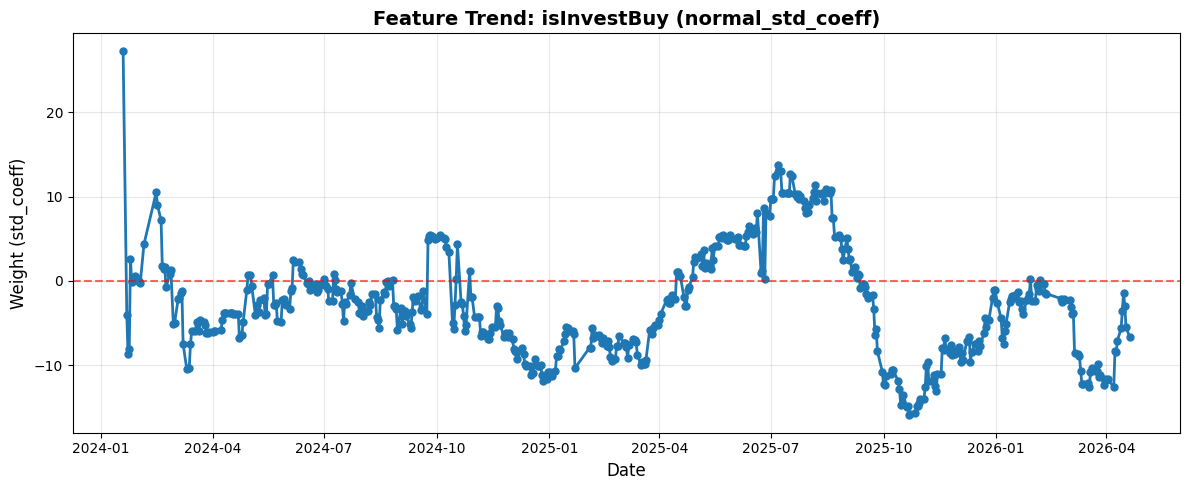

In [207]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_single_feature_trend(result_dict, feature_name, model_type='normal', coeff_type='std_coeff'):
    """
    根據 result 繪製單一特徵 (包含交互項) 的權重變化趨勢
    
    :param feature_name: 想要看的特徵名稱 (例如: 'ToLow', 'PLS_C1_Top_x_B1_A1B1')
    :param model_type: 'normal' 或 'ab' (Abnormal)
    :param coeff_type: 'std_coeff' 或是 'coeff'
    """
    coeff_key = f"{model_type}_{coeff_type}"
    
    dates = []
    vals = []
    
    # 從 coeff_log 中萃取每一天該特徵的值
    for d_str, entry in result_dict['coeff_log'].items():
        if coeff_key in entry and feature_name in entry[coeff_key]:
            dates.append(pd.to_datetime(d_str))
            vals.append(entry[coeff_key][feature_name])
            
    if not dates:
        print(f"⚠️ 在結果中找不到特徵 '{feature_name}'！請確認拼字或該特徵是否被篩選掉了。")
        return
        
    # 定義 DataFrame 以確保按日期順序排好
    df_plot = pd.DataFrame({'Date': dates, 'Value': vals}).sort_values('Date').set_index('Date')
    
    # 畫圖
    plt.figure(figsize=(12, 5))
    plt.plot(df_plot.index, df_plot['Value'], marker='o', linestyle='-', linewidth=2, markersize=5)
    
    # 畫上一條 Y=0 的輔助線，方便看是正相關還是負相關
    plt.axhline(0, color='red', linestyle='--', alpha=0.6)
    
    plt.title(f"Feature Trend: {feature_name} ({coeff_key})", fontsize=14, fontweight='bold')
    plt.xlabel("Date", fontsize=12)
    plt.ylabel(f"Weight ({coeff_type})", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ====== 使用範例 ======
# 看看 baseline 的 ToLow 特徵標準化權重趨勢
# plot_single_feature_trend(result, feature_name='ToLow')

# 如果確定交互項有長出來，就直接傳交互項的名字
plot_single_feature_trend(result, feature_name='isInvestBuy')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
  Rolling Model Dashboard — NORMAL Model
  交易日數: 539  |  特徵數: 8
  Feature Screening: ON (0/539 天有篩選)

📊 [1/4] Feature Selection Frequency


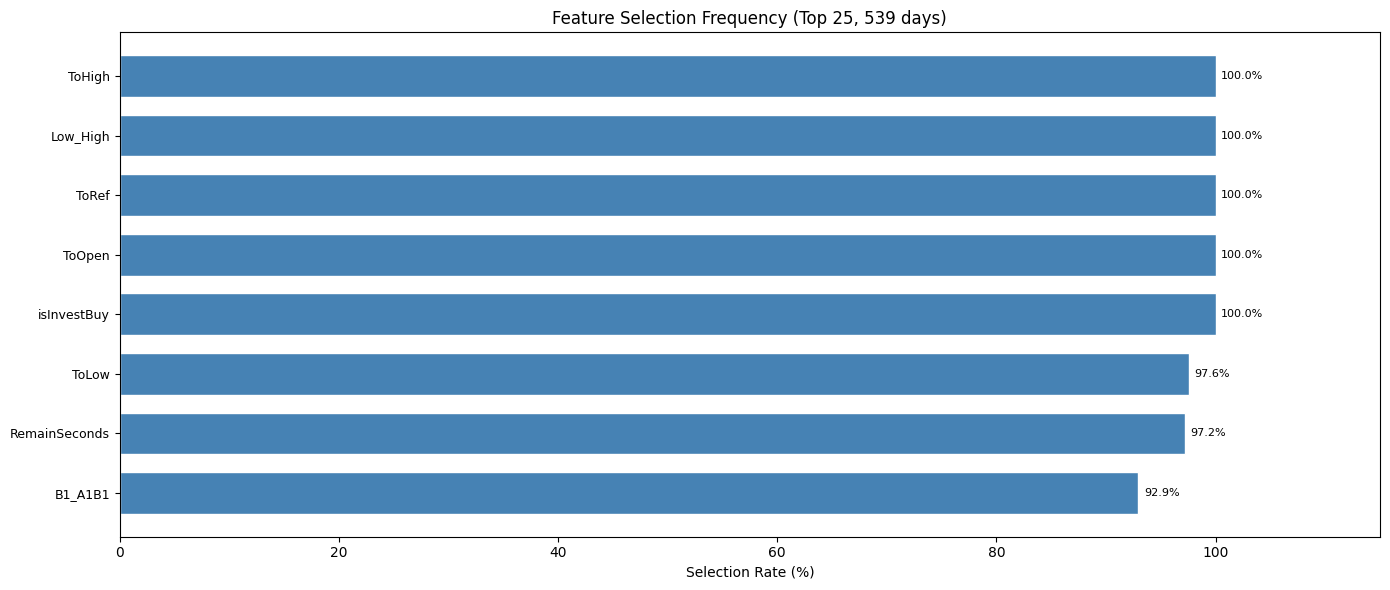


📊 [2/4] Feature Selection Heatmap


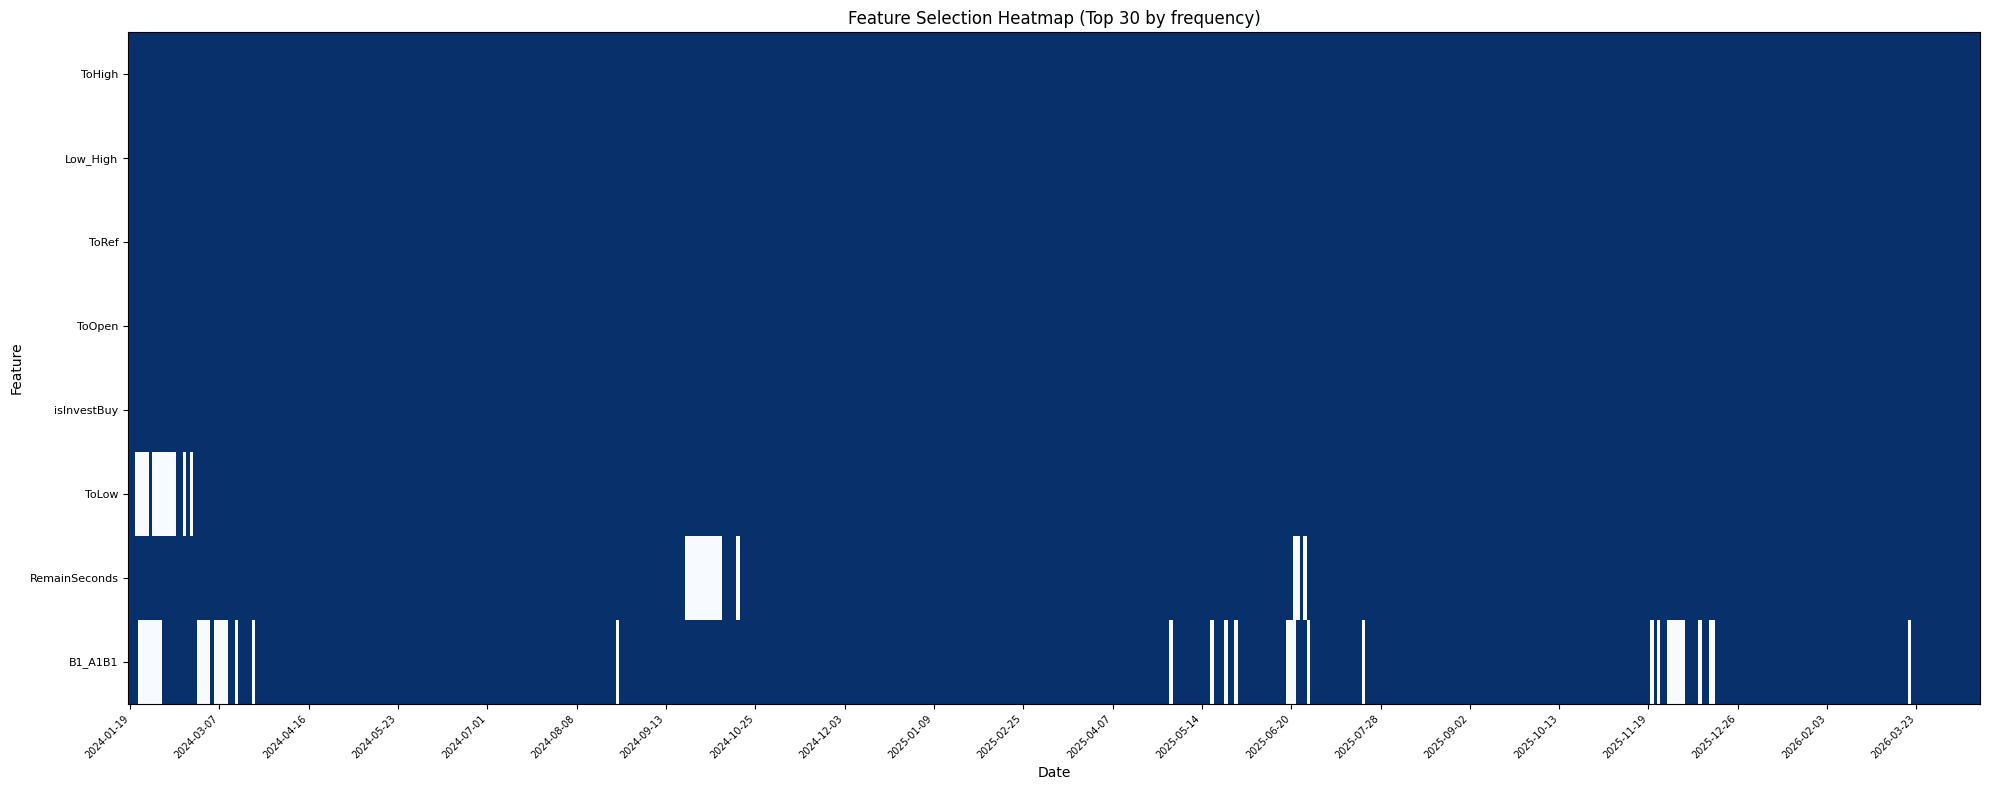


📊 [3/4] Standardized Coefficient Importance


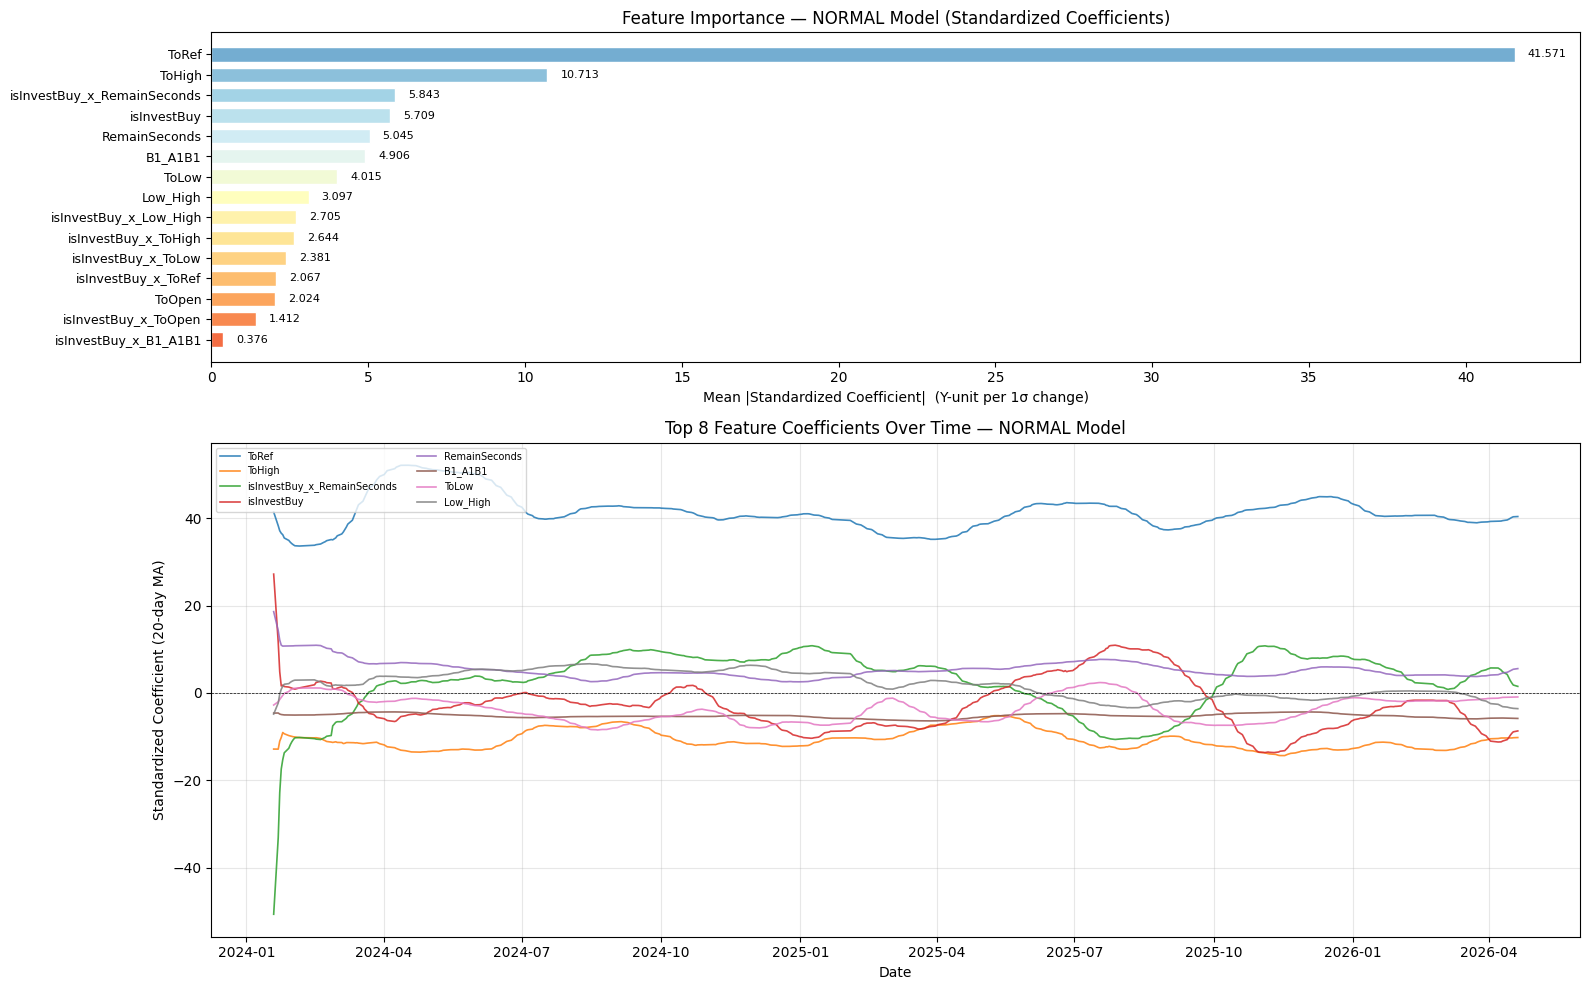


📊 [4/4] Coefficient Stability


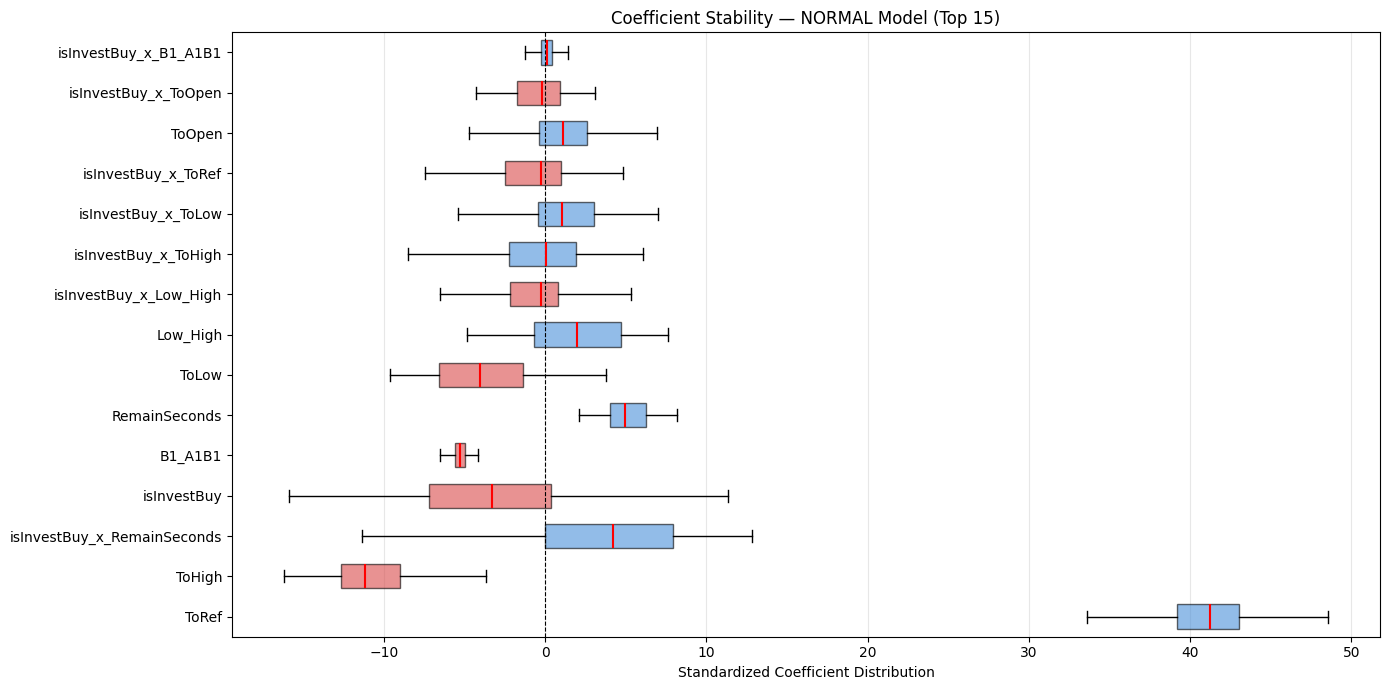

In [208]:
%load_ext autoreload
%autoreload 2
from src.research.negFill.model_analysis import plot_model_dashboard
# from model_analysis import plot_model_dashboard

plot_model_dashboard(result, model_type='normal')

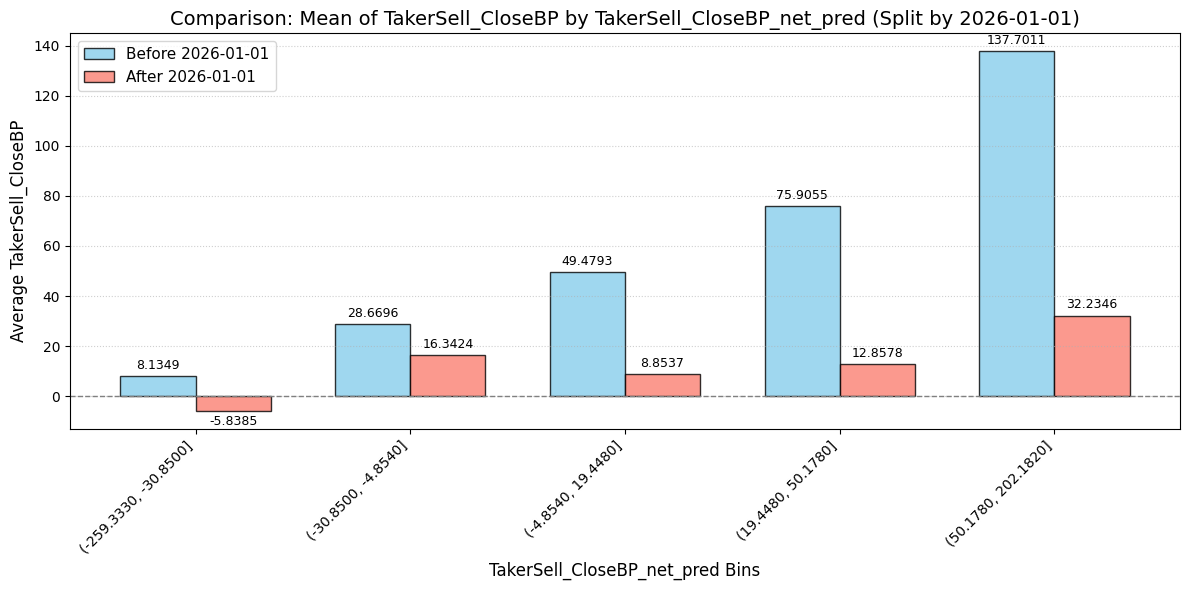

In [209]:
QcutAnalyzer.plot_qcut_analysis(signal_df.assign( TakerSell_CloseBP_net_pred = signal_df.TakerSell_CloseBP_net_pred + signal_df['20day_marketBeta'])[signal_df.isAbnormalDate == 0], 'TakerSell_CloseBP_net_pred', 'TakerSell_CloseBP', date_col='Date', split_date='2026-01-01')


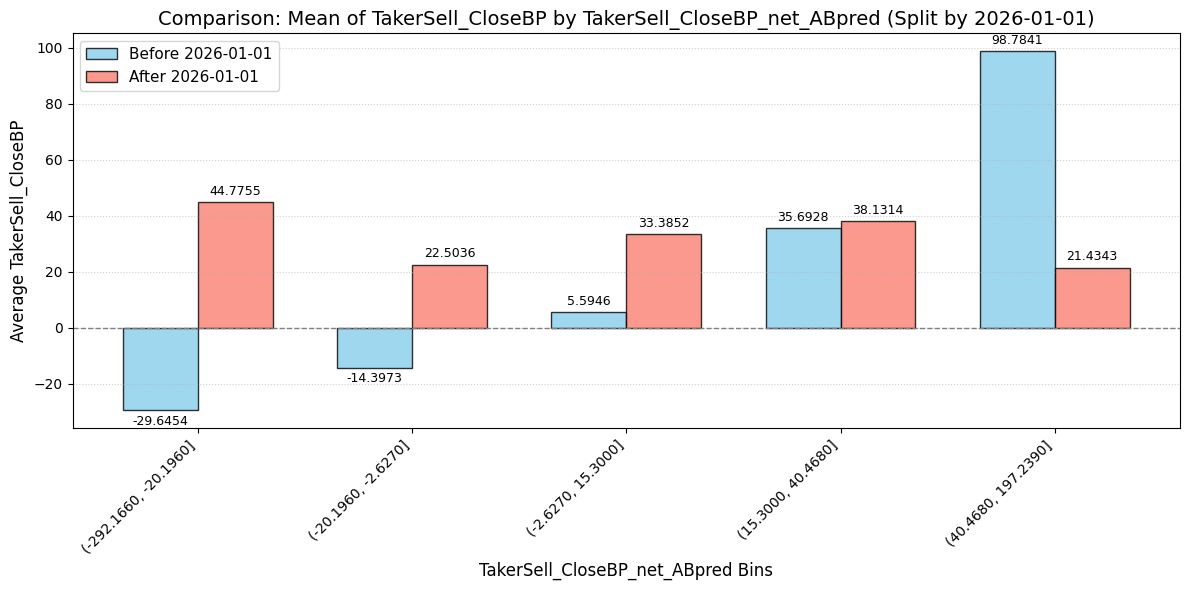

In [210]:
QcutAnalyzer.plot_qcut_analysis(signal_df.assign( TakerSell_CloseBP_net_pred = signal_df.TakerSell_CloseBP_net_pred + signal_df['20day_marketBeta'])[signal_df.isAbnormalDate == 1], 'TakerSell_CloseBP_net_ABpred', 'TakerSell_CloseBP', date_col='Date', split_date='2026-01-01')


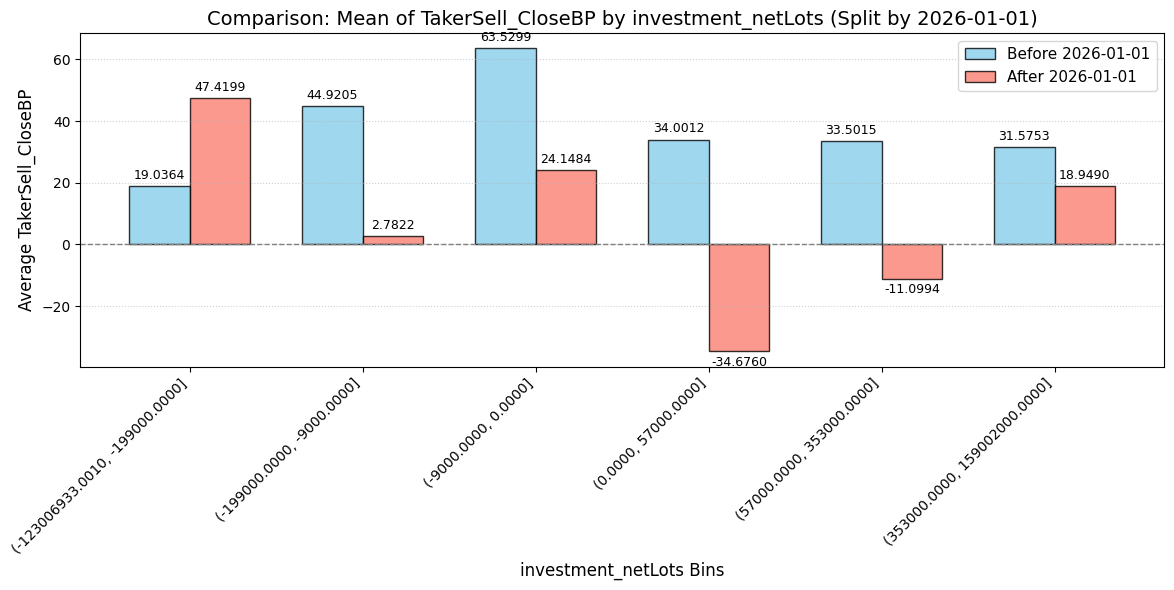

In [211]:
QcutAnalyzer.plot_qcut_analysis(signal_df, 'investment_netLots', 'TakerSell_CloseBP', date_col='Date', split_date='2026-01-01',q=10)


In [212]:
condition = pd.Series( [True for i in range(len(signal_df))] )
# condition =   (signal_df.ToOpen <0)# (signal_df.Position<200) #(signal_df.big_sell_ToCloseBP > 20 ) & (signal_df.InOut < 0 ) & (signal_df.FillLots > signal_df.big_sell_lots)
# condition = condition | ((signal_df.Spread <= 1 ) & ((signal_df.SpreadPairSeq>5) & (signal_df.SpreadPairID > 5)))
condition = condition & (( signal_df.TakerSell_CloseBP_net_pred * (signal_df.isAbnormalDate == 0 ) > -signal_df['20day_marketBeta']*0 + 40) | ( signal_df.TakerSell_CloseBP_net_ABpred * (signal_df.isAbnormalDate == 1 ) > -signal_df['20day_marketBeta']*0 + 40)) #&(signal_df.SpreadCountAtSameCount <= 1)#& (signal_df.TakerSell_CloseBP_net_pred > 0) #& ((signal_df.netTotalFillLotsRank>1800)|(signal_df.netAmountRank>1800))
print( signal_df[condition].TakerSell_CloseBP.describe() )
print('')
print( 'cap BP : '+str( round(signal_df[condition].groupby(['Date','QuoteCode']).TakerSell_CloseBP.first().mean() ) ) )
print( 'averge prod num : '+str( round(signal_df[condition].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

condition_recent = condition & (signal_df.Date > pd.to_datetime('2026-01-01')) # & (signal_df.Date.dt.strftime('%Y%m%d').astype(int) > 20260101) #& (signal_df.hft_participation > 0.3) & (signal_df.hft_sell_ToCloseBP > 0 )
print( signal_df[condition_recent].TakerSell_CloseBP.describe() ) 
print('')
print( 'cap BP : '+str( round(signal_df[condition_recent].groupby(['Date','QuoteCode']).TakerSell_CloseBP.first().mean() ) ) )
print( 'averge prod num : '+str( round(signal_df[condition_recent].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

count    2.687491e+06
mean     1.048027e+02
std      3.240806e+02
min     -8.987179e+02
25%     -6.033183e+01
50%      1.727862e+02
75%      3.125000e+02
max      1.423077e+03
Name: TakerSell_CloseBP, dtype: float64

cap BP : 76
averge prod num : 73.15
count    510179.000000
mean         24.357306
std         389.416432
min        -898.717949
25%        -324.087591
50%          37.831021
75%         286.975717
max        1422.459893
Name: TakerSell_CloseBP, dtype: float64

cap BP : 14
averge prod num : 74.43


In [ ]:
# signal_df = signal_df[ condition  ].sort_values(['Date','QuoteCode', 'TransTime']).reset_index(drop=True)
signal_df = signal_df[ condition ].sort_values(['Date','QuoteCode', 'TransTime']).reset_index(drop=True)& ((signal_df.AmountRank_canDayTrade<=100) |(signal_df.day_amount_rank <=100)) 

signal_df[ (signal_df.Date) ==signal_df.Date.max()][signal_df.QuoteCode=='3042']


In [169]:
signal_df.tail()

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,FillLots_origin,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,BidPreMove,AskPreMove,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadCountAtSameCount,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,SpreadPairTotalCount,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,trading_net_volume_noOdd,trading_net_volume_nearClose,avg_bidLots1,avg_askLots1,last_fillLots,last_FillPrice,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,hft_strick_participation,hft_strick_buy_ToCloseBP,hft_strick_buy_300sBP,hft_strick_sell_ToCloseBP,hft_strick_sell_300sBP,hft_strick_makerSpreadBP,firstMaker_buy_ToCloseBP,firstMaker_buy_300sBP,firstMaker_sell_ToCloseBP,firstMaker_sell_300sBP,firstMaker_makerSpreadBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,premium_ref_2330_buy_ToCloseBP,premium_open_2330_buy_ToCloseBP,discount_ref_2330_buy_ToCloseBP,discount_open_2330_buy_ToCloseBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,AmountRank_canDayTrade,Date,TakerSell_CloseBP_net,20day_marketBeta,isAbnormalDate,B1_Last,Total_Last,isInvestBuy,TakerSell_CloseBP_net_pred,TakerSell_CloseBP_net_ABpred
2660744,2026-04-20 01:18:41.180430,2026-04-20 09:18:41.098009,8358,8358,8363641,950994,0,0,-1,1,20706,382.0,381.5,381.0,380.5,380.0,6,18,30,10,33,383.0,383.5,384.0,384.5,385.0,3,34,90,5,12,382.0,15,0.0,0,0.0,0,"{""p"":3825000,""l"":3}",15,367.5,1,True,373.0,404.0,391.0,362.5,404.0,381.0,0.054422,0.023129,0.701754,-0.5,0.0,0.5,13.089005,382.50,0.039456,0.024129,-1,-873,-2226,0.666667,0.061856,0.247423,0.020833,0.256944,2.0,78,383.0,382.0,11,1.0,0.000000,0.241908,-1.0,604,120,696,14778,383.0,382.5,387.0,386.5,387.0,386.5,386.0,385.0,388.0,387.5,388.0,387.5,-416.230366,548.302872,6.535948,111.111111,111.111111,78.431373,-137.254902,137.254902,X,40256277.0,188078.0,31000.0,0.0,1322360.0,427634.0,380.0,465.0,X,39604.0,9742.0,555.0,382.428652,29.74222,124.0,NaN,10.0,NaN,NaN,10.0,-387.28798,109.429143,0.512456,345.722091,-318.669629,NaN,NaN,0.678455,333.921233,-469.762585,-381.142187,414.84571,-4.268658,343.758753,-419.809078,-383.520683,387.967576,36.459186,-1.0,NaN,NaN,350.716088,350.637411,NaN,NaN,12.0,37.0,2026-04-20 09:14:59.841938,09:15:00,4.0,1973.0,12.0,1955.0,69.0,54.0,34.0,28.0,309.0,389.0,4.0,2026-04-20,281.548663,-27.225195,0,0.015689,166.983871,1,84.949242,87.311226
2660745,2026-04-20 01:18:42.090225,2026-04-20 09:18:41.994171,8358,8358,8365623,951362,0,0,-1,0,20720,382.0,381.5,381.0,380.5,380.0,15,18,26,13,33,382.5,383.5,384.0,384.5,385.0,5,33,40,5,12,382.5,5,0.0,0,0.0,0,NaN,5,367.5,1,True,373.0,404.0,391.0,362.5,404.0,381.0,0.054422,0.023129,0.701754,-0.5,-1.0,0.5,13.0

沒 ：1582 3034 3221 3388 4540 4931  4939 5222 6205 6861 8028  
有 ：2395 3211 8150

signal_df[ (signal_df.Date == signal_df.Date.max()) & (signal_df.QuoteCode == '6861') ][['TransTime','QuoteCode','ChannelSeq','BidPrice1','TakerSell_CloseBP_net_pred','AmountRank_canDayTrade','day_amount_rank','hft_strick_makerSpreadBP','investment_netLots']].head()

In [188]:
signal_df['PosLots'] = signal_df.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumcount') + 1
signal_df['Position'] = signal_df.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumsum') / 10
signalwithRisk_df = signal_df[  
(signal_df.Position < 200)
#  (~((signal_df.PosLots >1) & (signal_df.Position > 50))) & (signal_df.BidPrice1<500)
# ( ((signal_df.Position < 500)&((signal_df.AmountRank < 50) | (signal_df.day_amount_rank<50))) |((signal_df.Position < 200)&((signal_df.AmountRank < 100) | (signal_df.day_amount_rank<100))) | ((signal_df.Position < 100)))
& (signal_df.BidPrice1<1000)  
& ( (signal_df.hft_strick_makerSpreadBP > -70) | (signal_df.hft_strick_makerSpreadBP.isna()))
& ((signal_df.investment_netLots <= 0 )) 
# & (signal_df.OTC ==1)
#  & ((signal_df.ToRef>0))
      ].reset_index(drop=True)
# signalwithRisk_df = signal_df[ (signal_df.PosLots ==1) & (signal_df.BidPrice1 <= 100)].reset_index(drop=True)
signalwithRisk_df['Date'] = signalwithRisk_df.Date.dt.strftime('%Y%m%d')


In [189]:
signalwithRisk_df[ signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max() ][['TransTime','QuoteCode','ValueCode','RecordLow','RecordHigh','RecordHigh','ChannelSeq','BidPrice1','TakerSell_CloseBP_net_pred'] +feature_columns].groupby('QuoteCode').first().sort_values(by='TransTime').reset_index(drop=True)

,TransTime,ValueCode,RecordLow,RecordHigh,RecordHigh,ChannelSeq,BidPrice1,TakerSell_CloseBP_net_pred,ToLow,ToHigh,Low_High,ToRef,ToOpen,B1_A1B1,RemainSeconds
0,2026-04-20 09:00:30.016423,1802,75.2,76.00,76.00,217902,75.20,41.458305,0.004043,0.006739,0.375000,0.013477,-0.003974,0.772321,15869
1,2026-04-20 09:00:30.227983,3450,375.0,385.00,385.00,218685,382.50,131.151855,0.024590,0.002732,0.900000,0.045082,0.020000,0.076923,15869
2,2026-04-20 09:00:30.277989,3211,370.0,375.00,375.00,98794,372.50,103.296059,0.009749,0.004178,0.700000,0.037604,0.006757,0.600000,15869
3,2026-04-20 09:00:30.891032,4958,290.0,296.50,296.50,221188,290.00,84.293404,0.001773,0.021277,0.076923,0.028369,-0.008547,0.029412,15869
4,2026-04-20 09:00:30.893739,6213,271.0,273.50,273.50,221192,272.50,43.848694,0.005545,0.003697,0.600000,0.007394,-0.001832,0.027778,15869
5,2026-04-20 09:00:31.747577,2049,295.5,297.00,297.00,224963,296.00,56.770752,0.005155,0.000000,1.000000,0.017182,-0.001686,0.575758,15868
6,2026-04-20 09:00:31.781008,6139,737.0,754.00,754.00,225126,736.00,40.243141,0.000000,0.023513,0.000000,0.017981,-0.023873,0.750000,15868
7,2026-04-20 09:00:31.908084,8155,387.5,390.50,390.50,101123,388.00,83.962433,0.002649,0.005298,0.333333,0.027815,-0.006402,0.333333,15868
8,2026-04-20 09:00:32.113213,3563,968.0,973.00,973.00,226328,968.00,46.610825,0.004180,0.001045,0.800000,0.011494,-0.005139,0.375000,15867
9,2026-04-20 09:00:32.556981,5498,69.8,70.20,70.20,102123,70.00,61.182671,0.001453,0.004360,0.250000,0.017442,0.000000,0.416667,15867




for d in signalwithRisk_df[lambda x : x.Date.astype(int) > 20260404].Date.unique() :
    signalwithRisk_df[lambda x : x.Date == d].reset_index(drop=True).to_csv(f'{d}_10w.csv')

In [190]:

signalwithRisk_df[ signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max() ].QuoteCode.unique()

<ArrowStringArray>
['1519', '1582', '1717', '1802', '2049', '2301', '2329', '2357', '2367',
 '2379', '2382', '2395', '2402', '2449', '2887', '3030', '3034', '3211',
 '3221', '3388', '3450', '3563', '3701', '3706', '4540', '4916', '4931',
 '4938', '4939', '4958', '4977', '5222', '5498', '6139', '6163', '6205',
 '6213', '6257', '6446', '6548', '6672', '6861', '8027', '8028', '8111',
 '8155']
Length: 46, dtype: str

In [191]:
signalwithRisk_df[ (signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max()) & (signalwithRisk_df.FutureHigh > signalwithRisk_df.RefPrice *1.08) ].QuoteCode.unique()

<ArrowStringArray>
['1582', '3221', '3388', '3450', '4939', '4958', '5498', '6163', '6205',
 '6672', '6861', '8155']
Length: 12, dtype: str

In [192]:
# 計算所有天數的排名比例
series1 = ( signalwithRisk_df.BidPrice1 * (signalwithRisk_df.TakerSell_CloseBP - 19.3) / 10000 / 10).groupby(signalwithRisk_df.Date).sum()
position = (signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum()

rank_series = series1.rank(pct=True)

dateSeq = -1

# 取得最後一天的排名
latest_date = series1.index[dateSeq]
latest_rank = rank_series.iloc[dateSeq]

print(f"日期: {latest_date}")
print(f"單邊部位: {position.iloc[dateSeq]:.2f} 萬")
print(f"損益: {series1.iloc[dateSeq]:.2f} 萬")
print(f"損益: {series1.iloc[dateSeq]/position.iloc[dateSeq]*100 :.2f} % ")

rank_series = series1.rank()
latest_rank2 = rank_series.iloc[dateSeq]
print(f"排名: {latest_rank2},  {latest_rank :.2%}") # 例如 85.00%，代表贏過歷史 85% 的天數




日期: 20260420
單邊部位: 7243.74 萬
損益: -50.05 萬
損益: -0.69 % 
排名: 28.0,  5.39%


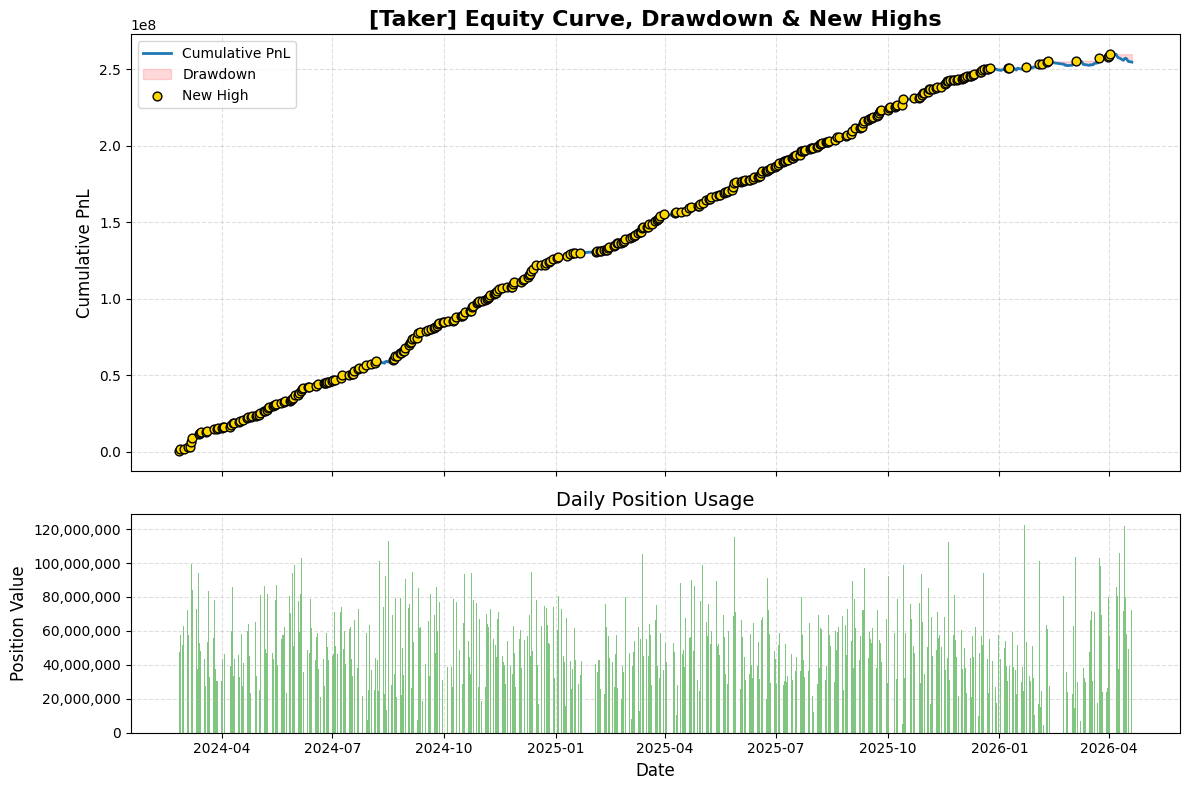


  回測模式: Taker
指標                 | 數值           

------------------ 基礎回報 ------------------
總報酬 (萬)           : 25,453.13
近一年報酬（萬）      : 9,568.03
風報比                  : 49.26
年化 Sharpe          : 10.44
創高最長費時 (天)     : 12
平均每日交易商品數   : 36.56

------------------ 勝率與效率 ------------------
年報酬率（基於平均部位）: 225.57%
近一年報酬率（近一年平均部位）: 185.60%
勝率 (日/單筆)      : 77.46% / 71.78%
平均BP (單筆/單位) : 97.88 / 93.9880

------------------ 風控與部位 ------------------
單日最大虧損（萬） : -222.89 萬
MDD金額/佔平均比   : -516.70 萬 / 9.90%
平均/最大部位(萬)  : 5,217.97 / 12,257.34
平均最大單一商品比  : 4.91%



In [193]:
bt = BackTest(signalwithRisk_df)
results = bt.run_analysis()

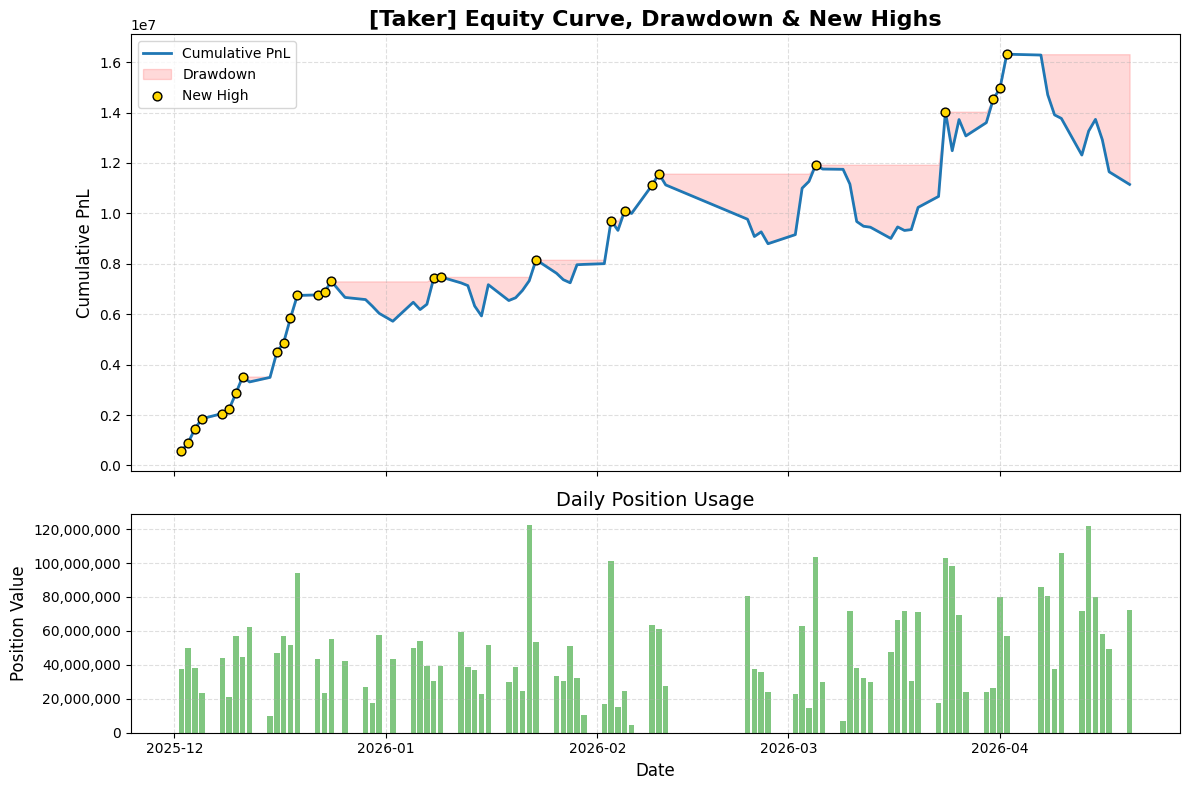


  回測模式: Taker
指標                 | 數值           

------------------ 基礎回報 ------------------
總報酬 (萬)           : 1,114.71
近一年報酬（萬）      : 1,114.71
風報比                  : 2.16
年化 Sharpe          : 2.55
創高最長費時 (天)     : 12
平均每日交易商品數   : 32.97

------------------ 勝率與效率 ------------------
年報酬率（基於平均部位）: 62.88%
近一年報酬率（近一年平均部位）: 23.06%
勝率 (日/單筆)      : 55.68% / 58.77%
平均BP (單筆/單位) : 42.11 / 26.1992

------------------ 風控與部位 ------------------
單日最大虧損（萬） : -157.49 萬
MDD金額/佔平均比   : -516.70 萬 / 10.69%
平均/最大部位(萬)  : 4,834.96 / 12,257.34
平均最大單一商品比  : 6.08%



In [194]:
bt = BackTest(signalwithRisk_df[signalwithRisk_df.Date.astype(int) > 20251201])
results = bt.run_analysis()


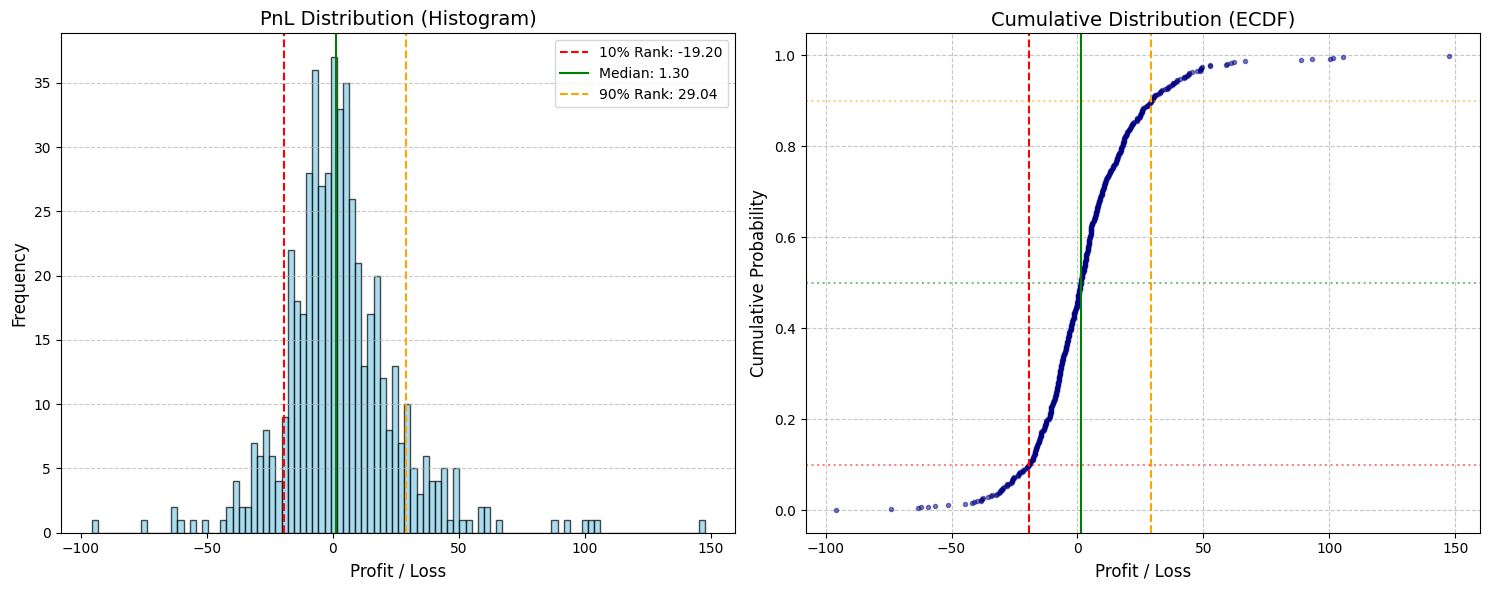

In [134]:

# 1. 計算分位數數值
q10 = series1.quantile(0.1)
q50 = series1.quantile(0.5)
q90 = series1.quantile(0.9)

# 2. 排序數據以計算累積機率 (ECDF)
sorted_data = np.sort(series1)
y_values = np.arange(len(sorted_data)) / float(len(sorted_data))

# 建立畫布
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- 圖左：直方圖 (棒狀圖) ---
axes[0].hist(series1, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
# 加入垂直分界線
axes[0].axvline(q10, color='red', linestyle='--', linewidth=1.5, label=f'10% Rank: {q10:.2f}')
axes[0].axvline(q50, color='green', linestyle='-', linewidth=1.5, label=f'Median: {q50:.2f}')
axes[0].axvline(q90, color='orange', linestyle='--', linewidth=1.5, label=f'90% Rank: {q90:.2f}')

axes[0].set_title('PnL Distribution (Histogram)', fontsize=14)
axes[0].set_xlabel('Profit / Loss', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend() # 顯示圖例
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- 圖右：累積圖 (ECDF) ---
axes[1].plot(sorted_data, y_values, marker='.', linestyle='none', color='navy', alpha=0.5)
# 加入垂直分界線 (X軸：損益數值)
axes[1].axvline(q10, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(q50, color='green', linestyle='-', linewidth=1.5)
axes[1].axvline(q90, color='orange', linestyle='--', linewidth=1.5)
# 加入水平參考線 (Y軸：排名百分比)
axes[1].axhline(0.1, color='red', linestyle=':', alpha=0.5)
axes[1].axhline(0.5, color='green', linestyle=':', alpha=0.5)
axes[1].axhline(0.9, color='orange', linestyle=':', alpha=0.5)

axes[1].set_title('Cumulative Distribution (ECDF)', fontsize=14)
axes[1].set_xlabel('Profit / Loss', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [33]:
# 計算所有天數的排名比例
series1 = ( signalwithRisk_df.BidPrice1 * (signalwithRisk_df.TakerSell_CloseBP - 19.3) / 10000 / 10).groupby(signalwithRisk_df.Date).sum()


In [34]:
date_portfolio = series1.reset_index().rename(columns={0: 'PL'})
date_portfolio['Position'] = ( signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum().reset_index(drop=True)
date_portfolio['Return'] = date_portfolio['PL'] / date_portfolio['Position'] * 100

【分析 A】2025 以後 兩者報酬與風險特性：
- 獲利率 Pearson 相關性: -0.4623
- 0030_portfolio  : 日波動 1.9440 | 年化波動度 30.8600
- date_portfolio  : 日波動 1.5527 | 年化波動度 24.6478

【分析 B】2025 以後 各自賠最多的 20% 交易日重疊狀況：
- 在 0030_portfolio 最差的 61 天中，有 6.56% 的機率 date_portfolio 也處於極端虧損
- 在 date_portfolio 最差的 62 天中，有 6.45% 的機率 0030 也處於極端虧損



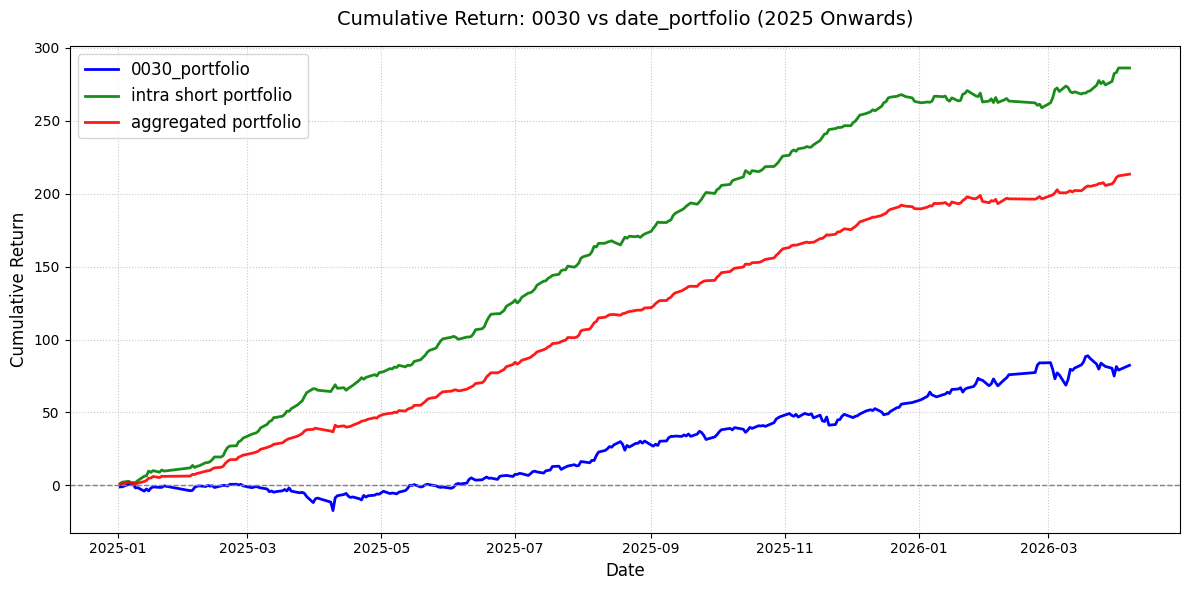

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. 讀取並處理 0030_portfolio.csv
# -------------------------------------------------------------------------
df_0030 = pd.read_csv('/home/kevin/Project/HFT/src/research/negFill/0030_portfolio.csv', encoding='utf-8-sig')

# 將 0030 的日期轉為 datetime 格式，方便後續篩選
df_0030['日期'] = pd.to_datetime(df_0030['日期'].astype(str), format='%Y%m%d')

# 👉 更正 1：篩選 2025 以後（包含 2025-01-01）
df_0030_filtered = df_0030[df_0030['日期'] >= '2025-01-01'].copy()
df_0030_filtered['獲利率'] = df_0030_filtered['獲利率'] * 100


# -------------------------------------------------------------------------
# 2. 處理 date_portfolio，對齊年份與格式
# -------------------------------------------------------------------------
# 👉 請確認這兩個變數對應您 date_portfolio 的實際欄位名稱：
date_col = 'Date'        # 日期欄位名稱
return_col = 'Return'    # 獲利率欄位名稱

dp_filtered = date_portfolio.copy()

# 若 date_portfolio 的日期在 index 上，請解除下面這行註解：
# dp_filtered = dp_filtered.reset_index() 

# 將該欄位轉為 datetime 格式，並篩選 2025 以後的資料
dp_filtered[date_col] = pd.to_datetime(dp_filtered[date_col].astype(str)) 
dp_filtered = dp_filtered[dp_filtered[date_col] >= '2025-01-01'].copy()


# -------------------------------------------------------------------------
# 合併兩者（取每日均有交易的交集日），並確保日期順序
# -------------------------------------------------------------------------
merged_df = pd.merge(
    df_0030_filtered[['日期', '獲利率']], 
    dp_filtered[[date_col, return_col]], 
    left_on='日期', 
    right_on=date_col, 
    how='inner'
)
merged_df = merged_df.sort_values('日期').reset_index(drop=True)


# =========================================================
# 分析 A：獲利率相關性與波動度
# =========================================================
correlation = merged_df['獲利率'].corr(merged_df[return_col])

# 👉 新增 2：計算波動度 (日標準差及乘上根號 252 的年化標準差)
vol_0030_daily = merged_df['獲利率'].std()
vol_0030_annual = vol_0030_daily * np.sqrt(252)

vol_dp_daily = merged_df[return_col].std()
vol_dp_annual = vol_dp_daily * np.sqrt(252)

print("【分析 A】2025 以後 兩者報酬與風險特性：")
print(f"- 獲利率 Pearson 相關性: {correlation:.4f}")
print(f"- 0030_portfolio  : 日波動 {vol_0030_daily:.4f} | 年化波動度 {vol_0030_annual:.4f}")
print(f"- date_portfolio  : 日波動 {vol_dp_daily:.4f} | 年化波動度 {vol_dp_annual:.4f}\n")


# =========================================================
# 分析 B：各自賠最多的 20% 交易日的重疊率 (基於原始 2025 以後的區間)
# =========================================================
thresh_0030 = df_0030_filtered['獲利率'].quantile(0.2)
thresh_dp = dp_filtered[return_col].quantile(0.2)

worst_days_0030 = set(df_0030_filtered[df_0030_filtered['獲利率'] <= thresh_0030]['日期'])
worst_days_dp = set(dp_filtered[dp_filtered[return_col] <= thresh_dp][date_col])

overlap_days = worst_days_0030.intersection(worst_days_dp)
union_days = worst_days_0030.union(worst_days_dp)

rate_0030 = len(overlap_days) / len(worst_days_0030) if len(worst_days_0030) > 0 else 0
rate_dp = len(overlap_days) / len(worst_days_dp) if len(worst_days_dp) > 0 else 0

print("【分析 B】2025 以後 各自賠最多的 20% 交易日重疊狀況：")
print(f"- 在 0030_portfolio 最差的 {len(worst_days_0030)} 天中，有 {rate_0030:.2%} 的機率 date_portfolio 也處於極端虧損")
print(f"- 在 date_portfolio 最差的 {len(worst_days_dp)} 天中，有 {rate_dp:.2%} 的機率 0030 也處於極端虧損\n")


# =========================================================
# 分析 C：繪製 2025 以後累計獲利率 (CumSum) 比較圖
# =========================================================
# 👉 新增 3：計算 CumSum 並畫在同一張圖
merged_df['0030_cumsum'] = merged_df['獲利率'].cumsum()
merged_df['dp_cumsum'] = merged_df[return_col].cumsum()

plt.figure(figsize=(12, 6))

# 把累進獲利畫出來
plt.plot(merged_df['日期'], merged_df['0030_cumsum'], label='0030_portfolio', color='blue', linewidth=2)
plt.plot(merged_df['日期'], merged_df['dp_cumsum'], label='intra short portfolio', color='green', linewidth=2, alpha=0.9)
plt.plot(merged_df['日期'],  (merged_df['0030_cumsum'] + merged_df['dp_cumsum']*1.8) / 2.8, label='aggregated portfolio', color='red', linewidth=2, alpha=0.9)

# 圖表美化
plt.title('Cumulative Return: 0030 vs date_portfolio (2025 Onwards)', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.axhline(0, color='grey', linestyle='--', linewidth=1) # 補上 0 軸線方便看有沒有賺錢
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)

# 調整佈局並顯示
plt.tight_layout()
plt.show()



In [36]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import polars as pl
from tqdm import tqdm

PROJECT_ROOT = Path(os.path.abspath('')).parents[2]

import glob
# ======================================================================
# 1. 預先計算台積電 (2330) 的歷史季線 (60MA)
# (加入防呆機制，跳過欄位毀損的日期檔案，避免 SchemaError 崩潰)
# ======================================================================
print("預先計算台積電 60MA 中...")
files = glob.glob(f'{PROJECT_ROOT}/data/marketData/*_marketData.parquet')
dfs = []
for f in tqdm(files, desc="讀取台積電歷史"):
    try:
        # 只讀取需要的欄位並且立刻過濾 2330，節省大量記憶體！
        df_day = pl.read_parquet(f, columns=['date', 'quote_code', 'close_price'])
        tsmc_day = df_day.filter(pl.col('quote_code') == '2330')
        dfs.append(tsmc_day)
    except Exception as e:
        # 遇到破掉或缺少欄位的假期檔案直接略過
        pass
# 將所有天數合併並照日期排序
tsmc_hist = pl.concat(dfs, how="diagonal_relaxed").sort('date').to_pandas()
# 計算 60 天移動平均線 (季線)
tsmc_hist['MA60'] = tsmc_hist['close_price'].rolling(window=60).mean()
# 轉成字串字典
tsmc_hist['date_str'] = pd.to_datetime(tsmc_hist['date']).dt.strftime('%Y%m%d')
tsmc_ma60_dict = dict(zip(tsmc_hist['date_str'], tsmc_hist['MA60']))
# ======================================================================

# ======================================================================
# 2. 開始執行你的主要迴圈
# ======================================================================
dateData = []
for d in tqdm( date_portfolio.Date[:-1] ): 
    # 轉為字串以防找不到，請依據你 df 中 date 的實際樣子調整
    d_str = str(d).replace("-", "") 
    
    # 讀取 marketData
    maket_df = pd.read_parquet(f'{PROJECT_ROOT}/data/marketData/{d_str}_marketData.parquet')
    premarket_df = pd.read_parquet(f'{PROJECT_ROOT}/data/preMarket/{d_str}_preMarketData.parquet')
    
    maket_df['quote_code'] = maket_df['quote_code'].astype(str)
    premarket_df['QuoteCode'] = premarket_df['QuoteCode'].astype(str)
    
    merged_df = pd.merge(
        maket_df, 
        premarket_df, 
        left_on='quote_code', 
        right_on='QuoteCode', 
        how='inner'
    )
    
    merged_df['toOpen'] = (merged_df['open_price'] - merged_df['opening_ref_price']) / merged_df['opening_ref_price']
    merged_df['Return'] = (merged_df['close_price'] - merged_df['opening_ref_price']) / merged_df['opening_ref_price']

    # 取出 2330
    tsmc = merged_df[merged_df['quote_code'] == '2330']
    tsmcOpen = tsmc.toOpen.iloc[0]
    tsmcReturn = tsmc.Return.iloc[0]
    tsmcClose = tsmc.close_price.iloc[0]
    
    # ======== 新增：計算距離季線(60MA)的乖離幅度 ========
    # 從剛剛預先做好的字典取出當天的 60MA
    ma60_today = tsmc_ma60_dict.get(d_str)
    
    if pd.notna(ma60_today) and ma60_today > 0:
        # 乖離率 = (收盤價 - 季線) / 季線
        tsmc_dist_60MA = (tsmcClose - ma60_today) / ma60_today
    else:
        # 前 60 天資料不足時先填空
        tsmc_dist_60MA = np.nan 
    # ===================================================

    # day_amount_rank < 100 的 mean
    top_df = merged_df[ (merged_df['day_amount_rank'] <= 100) & (merged_df.allow_day_trade_mark_x == 'X')]
    topOpen = top_df.toOpen.mean(numeric_only=True)
    topCount = top_df.toOpen.count()
    topDrop = top_df.toOpen.apply(np.sign).mean(numeric_only=True)
    topReturn = top_df.Return.mean(numeric_only=True)
    
    # 將算出的距離季線報酬率 (tsmc_dist_60MA) 塞進 dateData 中
    dateData.append([tsmcOpen, tsmcReturn, tsmc_dist_60MA, topOpen, topDrop, topReturn, topCount])



預先計算台積電 60MA 中...


100%|██████████| 784/784 [00:27<00:00, 29.01it/s]


In [37]:
date_portfolio = series1.reset_index().rename(columns={0: 'PL'})
date_portfolio['Position'] = ( signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum().reset_index(drop=True)
date_portfolio['Return'] = date_portfolio['PL'] / date_portfolio['Position'] * 100

In [38]:
date_portfolio = pd.concat( [date_portfolio, pd.DataFrame(columns=['tsmOpen', 'tsmReturn', 'tsmc_dist_60MA', 'topOpen', 'topDrop', 'topReturn','topCount'], data = dateData) ], axis = 1)

In [39]:
date_portfolio= date_portfolio.reset_index(drop=True)

In [40]:
date_portfolio['topStd_10D'] = (date_portfolio.topDrop).rolling(10,min_periods=1).std().shift()
date_portfolio['topReturnlast_10D'] = (date_portfolio.topReturn).rolling(10,min_periods=1).std().shift()

In [41]:
date_portfolio['Count'] =  (date_portfolio.topOpen < 0.0025) #| (date_portfolio.topReturnlast_10D > 0.015) 
# date_portfolio['Count'] =  (date_portfolio.topOpen < 0.00) | (date_portfolio.topReturnlast_10D < -0.025) 

In [42]:
date_portfolio[['Date', 'topOpen']].to_csv('open.csv')

In [43]:
date_portfolio['Count'].mean()

np.float64(0.36560509554140125)

<Axes: >

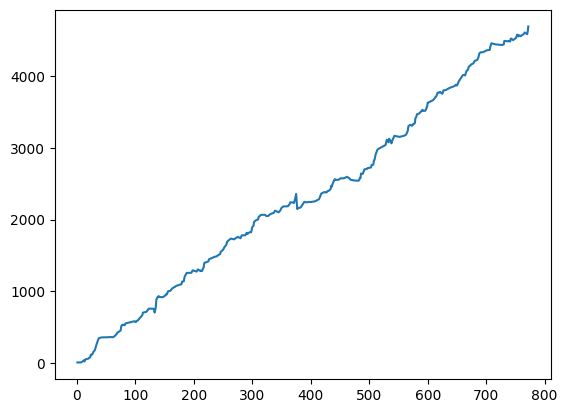

In [44]:
date_portfolio[ (date_portfolio.Count == 1) ].PL.cumsum().plot()
# date_portfolio[ (date_portfolio.topReturnlast_10D.rolling(window=100,min_periods=1).rank(ascending=True, pct=True) )<0.05 ].PL.cumsum().plot()

<Axes: >

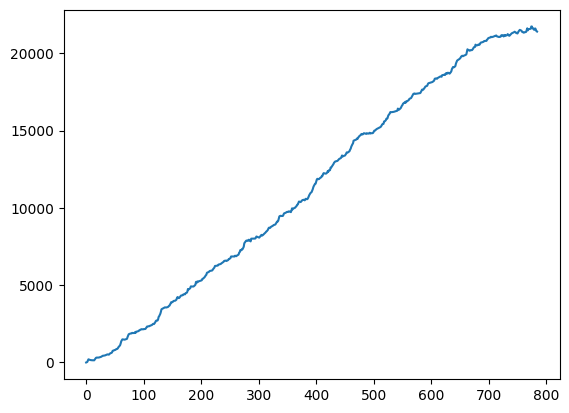

In [45]:
date_portfolio[ date_portfolio.Count == 0 ].PL.cumsum().plot()

In [46]:
abonraml_DATE = date_portfolio[ (date_portfolio.Count ==1) ].Date.to_list()

In [47]:
abonraml_DATE

['20230110',
 '20230117',
 '20230131',
 '20230203',
 '20230206',
 '20230207',
 '20230209',
 '20230215',
 '20230216',
 '20230217',
 '20230221',
 '20230222',
 '20230223',
 '20230301',
 '20230302',
 '20230307',
 '20230308',
 '20230310',
 '20230313',
 '20230314',
 '20230316',
 '20230323',
 '20230406',
 '20230417',
 '20230424',
 '20230426',
 '20230427',
 '20230503',
 '20230504',
 '20230510',
 '20230512',
 '20230515',
 '20230517',
 '20230523',
 '20230524',
 '20230601',
 '20230614',
 '20230619',
 '20230620',
 '20230626',
 '20230630',
 '20230706',
 '20230707',
 '20230717',
 '20230721',
 '20230728',
 '20230804',
 '20230807',
 '20230809',
 '20230810',
 '20230814',
 '20230816',
 '20230817',
 '20230825',
 '20230831',
 '20230904',
 '20230905',
 '20230907',
 '20230913',
 '20230918',
 '20230921',
 '20230922',
 '20230927',
 '20231004',
 '20231013',
 '20231016',
 '20231019',
 '20231020',
 '20231023',
 '20231026',
 '20231107',
 '20231109',
 '20231120',
 '20231122',
 '20231128',
 '20231129',
 '20231201',

import json

# 假設這是你的異常日期清單 (字串格式)

# 將 list 存成 JSON 檔案
with open('abnormal_dates.json', 'w') as f:
    json.dump(abonraml_DATE, f)
    
print("異常日期清單已儲存！")

In [48]:
condition = date_portfolio.test > -0.005
print(condition.sum())
date_portfolio[ condition ].PL.cumsum().plot()

AttributeError: 'DataFrame' object has no attribute 'test'